In [14]:
import pickle
import numpy as np

def normalize_per_signal(x):
    min_v = x.min(axis=1, keepdims=True)
    max_v = x.max(axis=1, keepdims=True)

    return 2 * (x - min_v) / (max_v - min_v + 1e-8) - 1

NSR_PATH = "Dataset/NSR__procesado.pkl"

with open(NSR_PATH, "rb") as f:
    data_A= pickle.load(f)


signals = np.array(data_A['data'])   # (N_A, 1000)
#signals_B = np.array(data_B['data']["PVC"])   # (N_B, 1000)


In [15]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset,Dataset

class ECGDataset(Dataset):
    def __init__(self, signals):
        # Asumimos que ya vienen normalizados entre [-1, 1]
        self.signals = torch.tensor(signals, dtype=torch.float32)
        if self.signals.ndim == 2:
            self.signals = self.signals.unsqueeze(1)

    def __len__(self):
        return len(self.signals)

    def __getitem__(self, idx):
        return self.signals[idx]


loader = DataLoader(ECGDataset(signals), batch_size=16, shuffle=True)

In [16]:
from fastdtw import fastdtw

def calculate_dtw_score(real_signals, fake_signals):
    dtw_distances = []
    # Comparamos un máximo de 4 señales para ahorrar tiempo de cómputo
    num_samples = min(len(real_signals), len(fake_signals), 4) 
    
    for i in range(num_samples):
        # r ya es real_signals[i], f es fake_signals[i]
        # Aseguramos que sean arrays de numpy planos y float64
        r = real_signals[i].detach().cpu().numpy().flatten().astype(np.float64)
        f = fake_signals[i].flatten().astype(np.float64)
        
        # Distancia euclidiana simple (valor absoluto para 1D)
        distancia, _ = fastdtw(r, f, dist=lambda x, y: np.abs(x - y))
        dtw_distances.append(distancia)
        
    return np.mean(dtw_distances)

Epoch 99 | Loss: 0.01751

--- Evaluando Época 100 ---
Época 100 - DTW Score Promedio: 1850.6649
⭐ ¡Nuevo mejor modelo guardado! (DTW: 1850.6649)


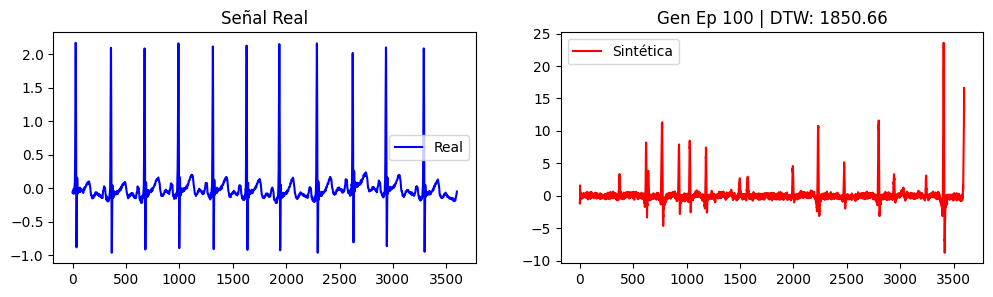

Epoch 199 | Loss: 0.01451

--- Evaluando Época 200 ---
Época 200 - DTW Score Promedio: 2295.3872


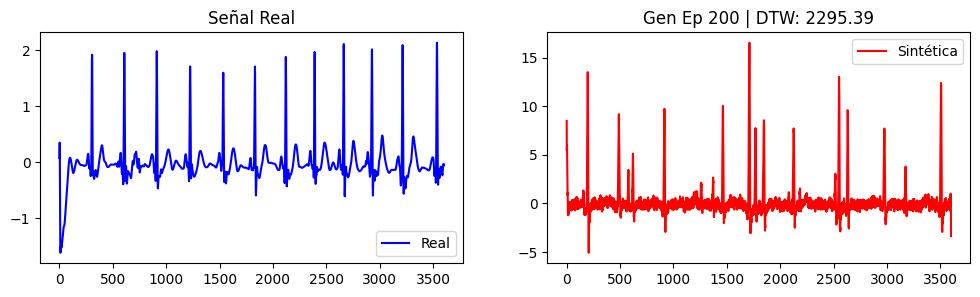

Epoch 299 | Loss: 0.01077

--- Evaluando Época 300 ---
Época 300 - DTW Score Promedio: 1188.6800
⭐ ¡Nuevo mejor modelo guardado! (DTW: 1188.6800)


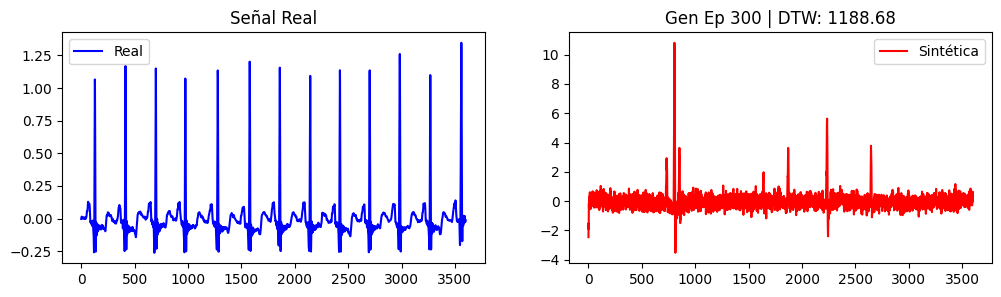

Epoch 399 | Loss: 0.01899

--- Evaluando Época 400 ---
Época 400 - DTW Score Promedio: 1423.5130


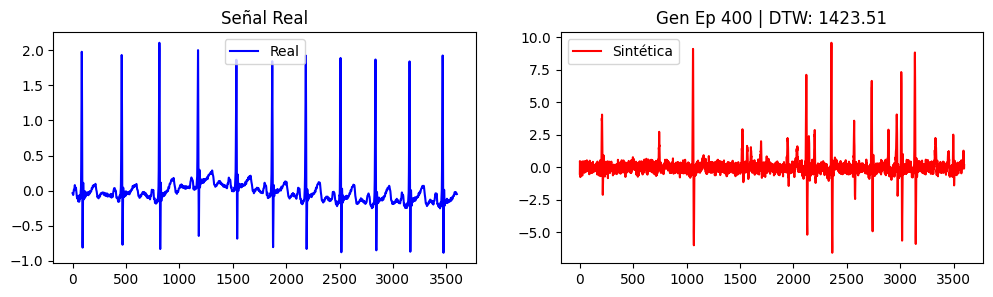

Epoch 499 | Loss: 0.02573

--- Evaluando Época 500 ---
Época 500 - DTW Score Promedio: 1779.6332


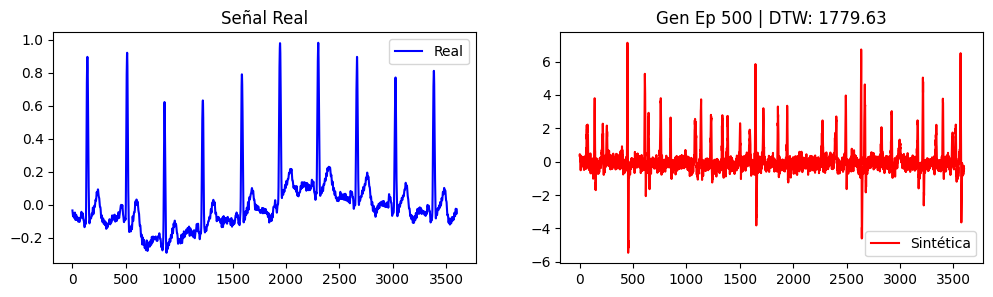

Epoch 599 | Loss: 0.01351

--- Evaluando Época 600 ---
Época 600 - DTW Score Promedio: 1162.5510
⭐ ¡Nuevo mejor modelo guardado! (DTW: 1162.5510)


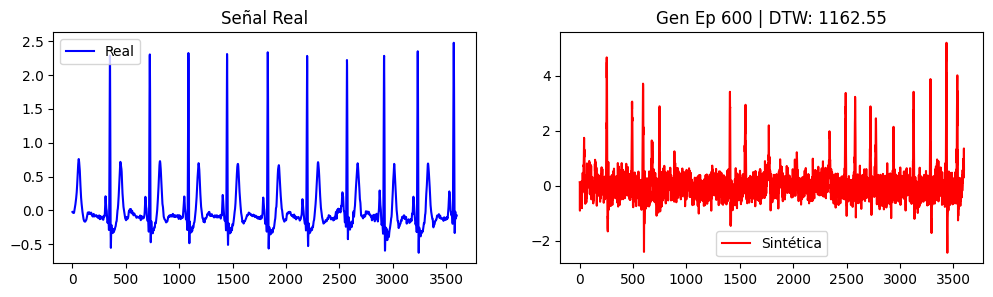

Epoch 699 | Loss: 0.01002

--- Evaluando Época 700 ---
Época 700 - DTW Score Promedio: 1016.8655
⭐ ¡Nuevo mejor modelo guardado! (DTW: 1016.8655)


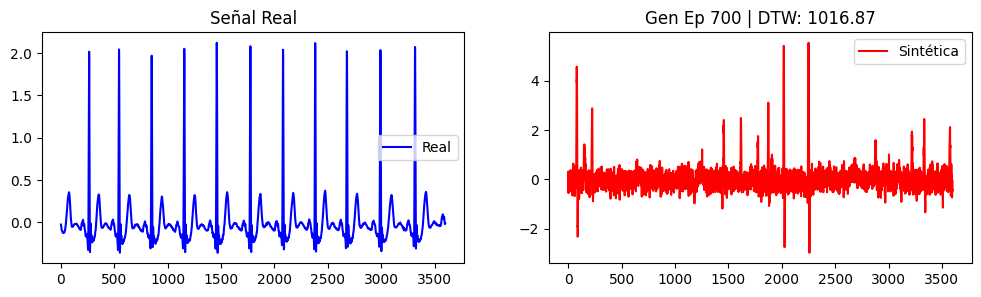

Epoch 799 | Loss: 0.01872

--- Evaluando Época 800 ---
Época 800 - DTW Score Promedio: 1264.8055


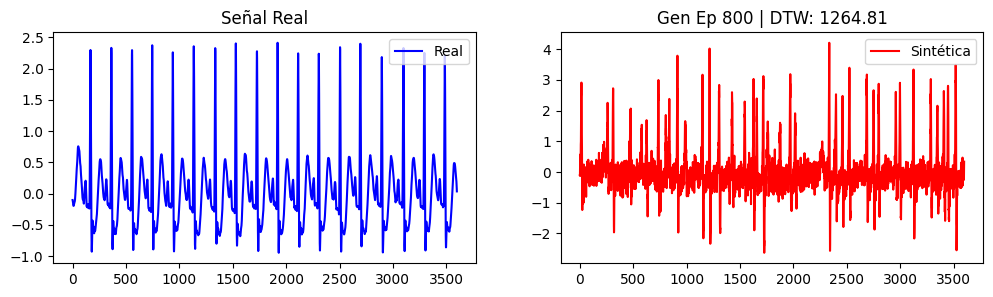

Epoch 899 | Loss: 0.01495

--- Evaluando Época 900 ---
Época 900 - DTW Score Promedio: 1137.7085


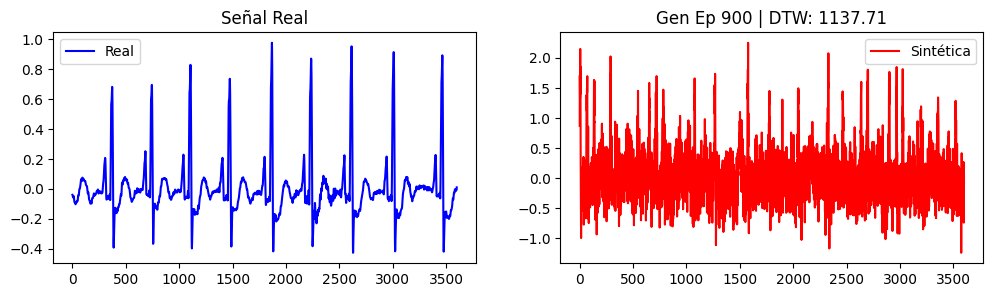

Epoch 999 | Loss: 0.00924

--- Evaluando Época 1000 ---
Época 1000 - DTW Score Promedio: 1123.3286


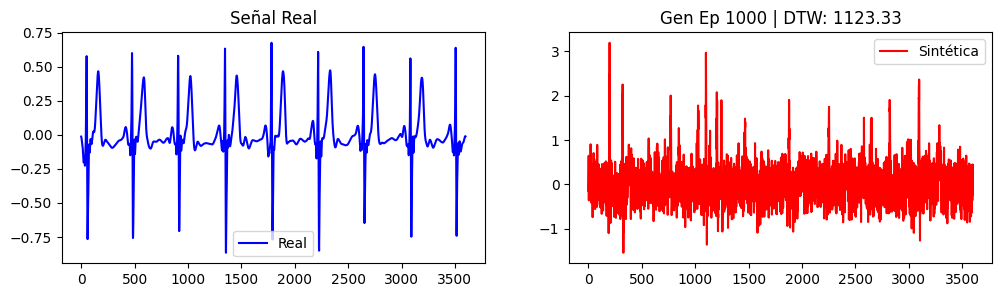

Epoch 1099 | Loss: 0.01469

--- Evaluando Época 1100 ---
Época 1100 - DTW Score Promedio: 1075.5336


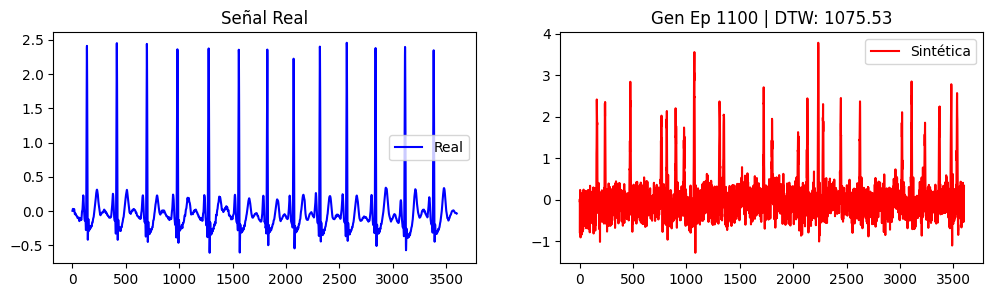

Epoch 1199 | Loss: 0.02303

--- Evaluando Época 1200 ---
Época 1200 - DTW Score Promedio: 1202.5959


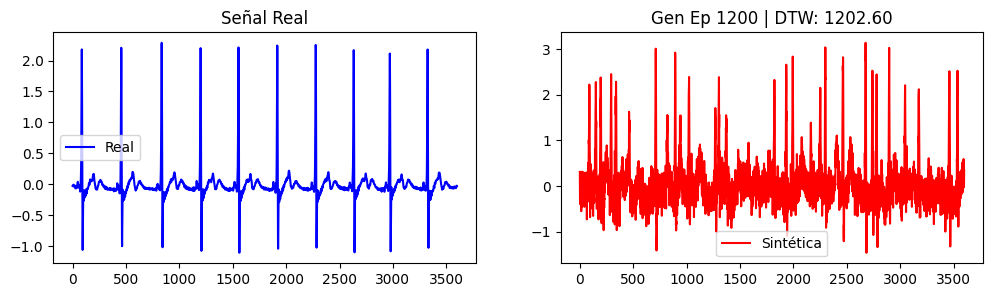

Epoch 1299 | Loss: 0.01838

--- Evaluando Época 1300 ---
Época 1300 - DTW Score Promedio: 994.3540
⭐ ¡Nuevo mejor modelo guardado! (DTW: 994.3540)


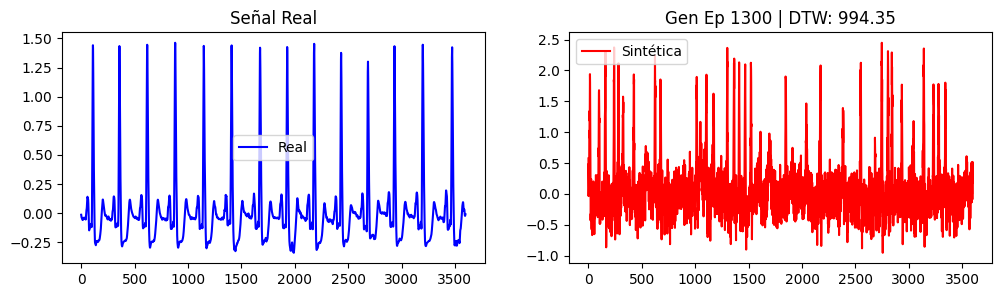

Epoch 1399 | Loss: 0.01430

--- Evaluando Época 1400 ---
Época 1400 - DTW Score Promedio: 1164.6531


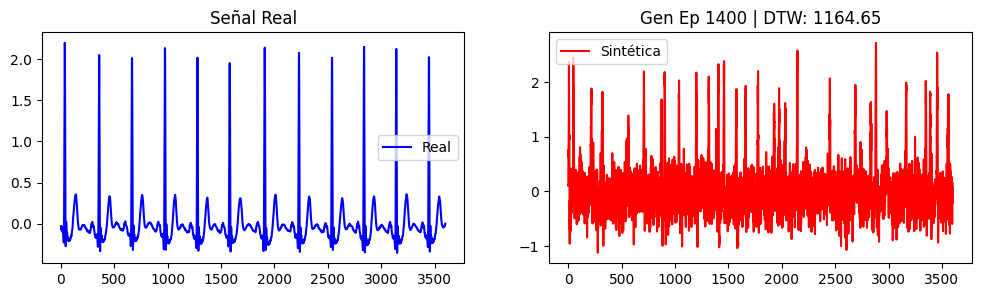

Epoch 1499 | Loss: 0.00956

--- Evaluando Época 1500 ---
Época 1500 - DTW Score Promedio: 975.7884
⭐ ¡Nuevo mejor modelo guardado! (DTW: 975.7884)


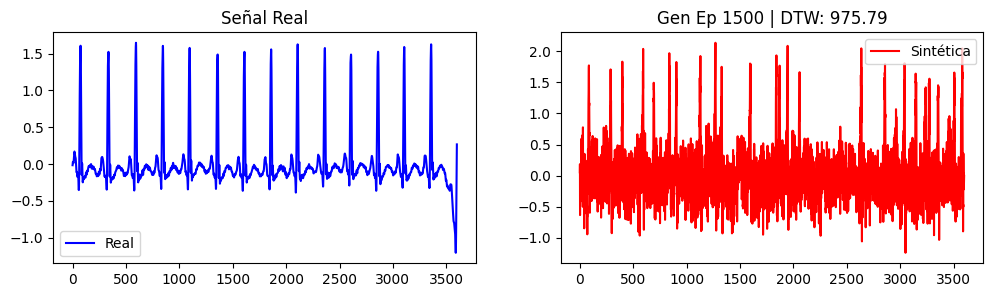

Epoch 1599 | Loss: 0.01144

--- Evaluando Época 1600 ---
Época 1600 - DTW Score Promedio: 1258.5486


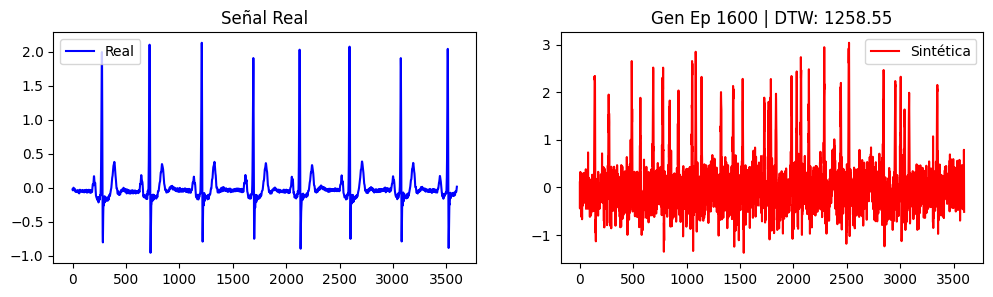

Epoch 1699 | Loss: 0.00812

--- Evaluando Época 1700 ---
Época 1700 - DTW Score Promedio: 1077.1925


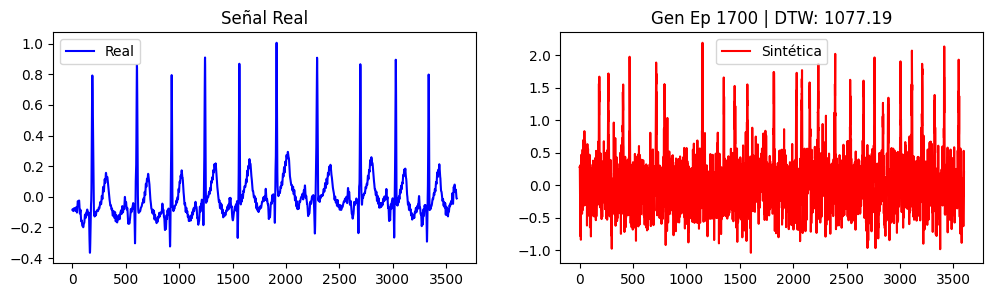

Epoch 1799 | Loss: 0.01321

--- Evaluando Época 1800 ---
Época 1800 - DTW Score Promedio: 1089.4715


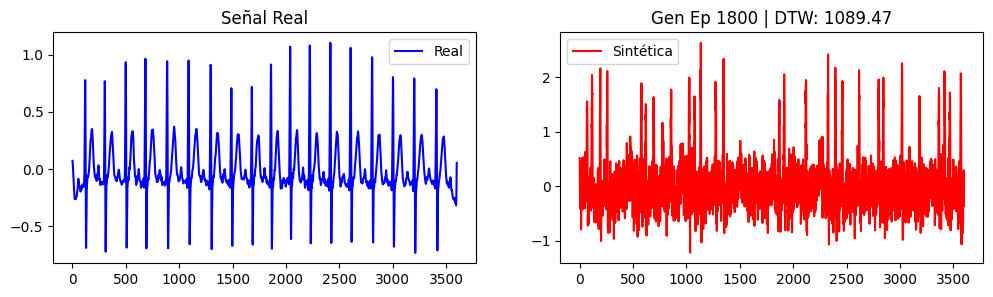

Epoch 1899 | Loss: 0.00743

--- Evaluando Época 1900 ---
Época 1900 - DTW Score Promedio: 1062.8839


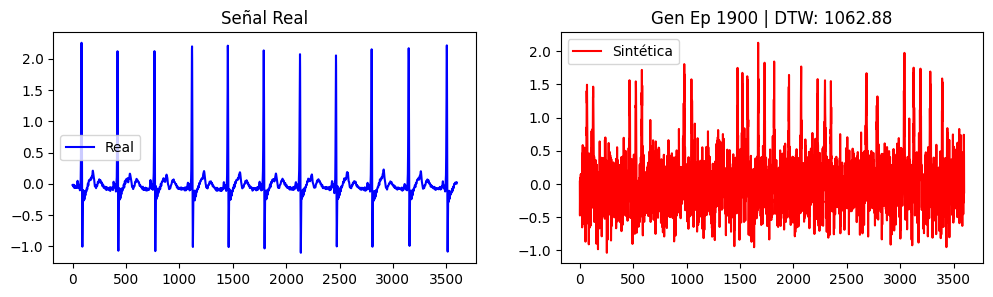

Epoch 1999 | Loss: 0.01282

--- Evaluando Época 2000 ---
Época 2000 - DTW Score Promedio: 1352.4236


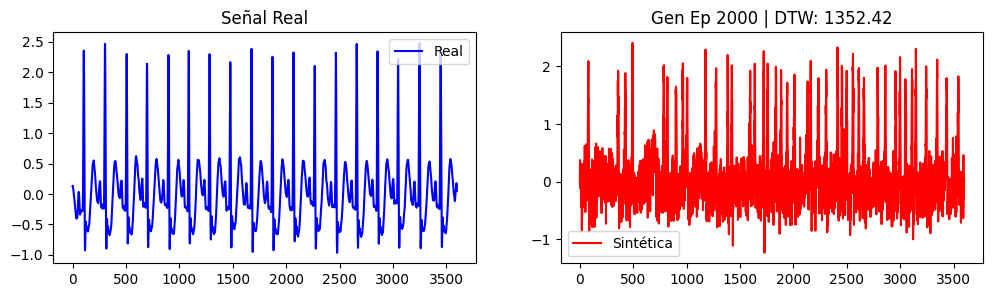

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# 1. CONFIGURACIÓN DEL SCHEDULER DE COSENO (Mejora la retención de estructura)
def get_cosine_schedule(T, s=0.008):
    steps = T + 1
    x = torch.linspace(0, T, steps)
    alphas_cumprod = torch.cos(((x / T) + s) / (1 + s) * np.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.02)

# Mover los coeficientes de difusión al dispositivo (GPU o CPU)


best_dtw = float('inf')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

T = 1000
betas = get_cosine_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)

sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod).to(device)

sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod).to(device)


# 2. ARQUITECTURA U-NET MEJORADA (Con Convoluciones Dilatadas)
class ResNetBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(channels, channels, 3, padding=2, dilation=2),
            nn.BatchNorm1d(channels),
            nn.LeakyReLU(0.2),
            nn.Conv1d(channels, channels, 3, padding=1),
            nn.BatchNorm1d(channels)
        )
    def forward(self, x):
        return x + self.conv(x)

class BioDiffusionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        # Encoder
        self.init_conv = nn.Conv1d(1, 64, 7, padding=3)
        self.down1 = nn.Conv1d(64, 128, 4, stride=2, padding=1) 
        self.res1 = ResNetBlock(128)
        self.down2 = nn.Conv1d(128, 256, 4, stride=2, padding=1)
        self.res2 = ResNetBlock(256)
        
        # Bottleneck
        self.mid_res = ResNetBlock(256)
        
        # Decoder
        self.up1 = nn.ConvTranspose1d(256, 128, 4, stride=2, padding=1)
        self.up2 = nn.ConvTranspose1d(128, 64, 4, stride=2, padding=1)
        self.out_conv = nn.Conv1d(64, 1, 3, padding=1)

    def forward(self, x, t):
        # En una implementación avanzada t se sumaría aquí, 
        # pero para 50 épocas, la U-Net aprenderá la morfología por el ruido.
        x = self.init_conv(x)
        x1 = self.res1(self.down1(x))
        x2 = self.res2(self.down2(x1))
        x = self.mid_res(x2)
        x = self.up1(x)
        if x.shape[-1] != x1.shape[-1]: x = F.interpolate(x, size=x1.shape[-1])
        x = self.up2(x)
        if x.shape[-1] != 3600: x = F.interpolate(x, size=3600)
        return self.out_conv(x)

# 3. FUNCIÓN DE MUESTREO (SAMPLING) ESTOCÁSTICO
@torch.no_grad()
def sample_ecg(model, n_samples=1, device="cpu"):
    model.eval()
    x = torch.randn(n_samples, 1, 3600).to(device)
    for i in reversed(range(T)):
        t = torch.full((n_samples, 1), i / T).to(device)
        pred_noise = model(x, t)
        
        a = alphas[i].to(device)
        a_cap = alphas_cumprod[i].to(device)
        b = betas[i].to(device)
        
        noise = torch.randn_like(x) if i > 0 else 0
        # Ecuación de Langevin para limpiar el ruido
        x = (1 / torch.sqrt(a)) * (x - ((1 - a) / torch.sqrt(1 - a_cap)) * pred_noise) + torch.sqrt(b) * noise
    return x.cpu().squeeze().numpy()

# 4. ENTRENAMIENTO

model = BioDiffusionUNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4) # AdamW es más estable
criterion = nn.HuberLoss() # Menos sensible a picos que el MSE

# (Asumiendo que 'dataloader' ya está definido con tus datos de 3600)
epochs = 2000
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in loader:
        x_0 = batch[0].to(device)
        t = torch.randint(0, T, (x_0.shape[0],)).to(device)
        
        # Añadir ruido
        noise = torch.randn_like(x_0)
        sqrt_a_cap = sqrt_alphas_cumprod[t].view(-1, 1, 1).to(device)
        sqrt_one_minus_a_cap = sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1).to(device)
        x_noisy = sqrt_a_cap * x_0 + sqrt_one_minus_a_cap * noise
        
        # Predecir y optimizar
        predicted_noise = model(x_noisy, t.float().unsqueeze(1) / T)
        loss = criterion(predicted_noise, noise)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch+1) % 100 == 0:
        print(f"Epoch {epoch} | Loss: {total_loss/len(loader):.5f}")


        print(f"\n--- Evaluando Época {epoch+1} ---")
        model.eval()
        
        with torch.no_grad():
            # 1. Generar muestras sintéticas usando el proceso de difusión
            # Generamos pocas (ej. 4) para que el cálculo de DTW no sea eterno
            gen_samples = sample_ecg(model, n_samples=4, device=device)
            
            # 2. Tomar muestras reales del último batch para comparar
            # x_0 viene de tu bucle de entrenamiento
            real_samples = x_0 

            # 3. Calcular DTW Score
            current_dtw = calculate_dtw_score(real_samples, gen_samples)
            print(f"Época {epoch+1} - DTW Score Promedio: {current_dtw:.4f}")

            # 4. Guardar el mejor modelo según DTW
            if current_dtw < best_dtw:
                best_dtw = current_dtw
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'dtw_score': best_dtw,
                }, 'best_model_biodiffusion.pth')
                print(f"⭐ ¡Nuevo mejor modelo guardado! (DTW: {best_dtw:.4f})")

            # 5. Visualización rápida
            plt.figure(figsize=(12, 3))
            plt.subplot(1, 2, 1)
            plt.plot(real_samples[0].cpu().squeeze().numpy(), label="Real", color='blue')
            plt.title("Señal Real")
            plt.legend()
            
            plt.subplot(1, 2, 2)
            plt.plot(gen_samples[0], label="Sintética", color='red')
            plt.title(f"Gen Ep {epoch+1} | DTW: {current_dtw:.2f}")
            plt.legend()
            plt.show()


        

Epoch 100 | Loss: 0.01638 | DTW: 430.58
⭐ ¡Mejor modelo guardado!


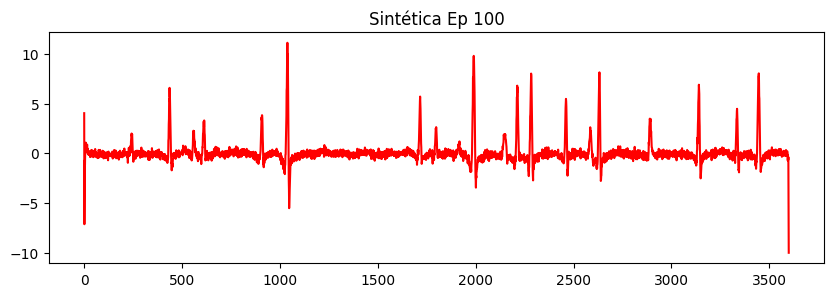

Epoch 200 | Loss: 0.03095 | DTW: 788.52


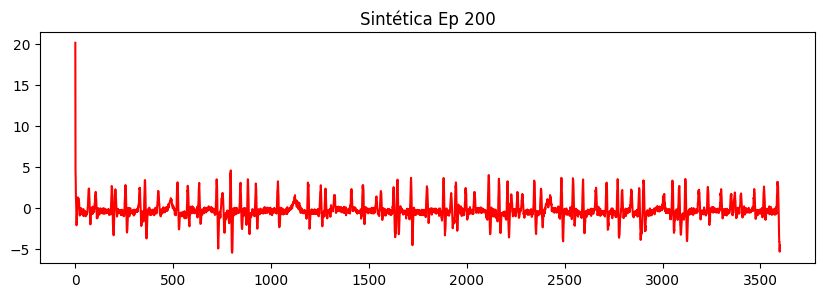

Epoch 300 | Loss: 0.01523 | DTW: 273.10
⭐ ¡Mejor modelo guardado!


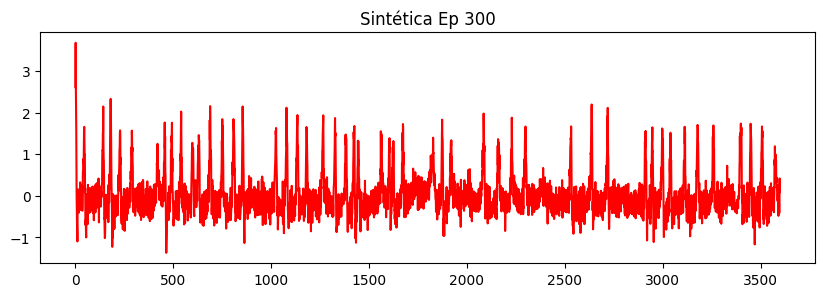

Epoch 400 | Loss: 0.01707 | DTW: 293.04


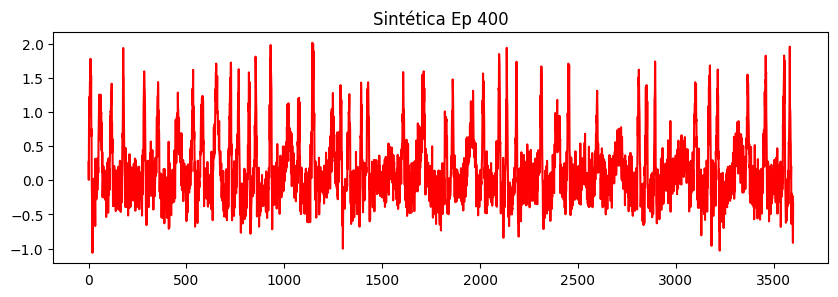

Epoch 500 | Loss: 0.01085 | DTW: 296.07


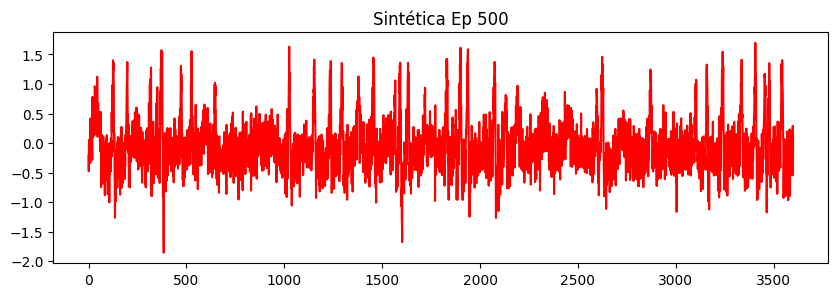

Epoch 600 | Loss: 0.01814 | DTW: 296.69


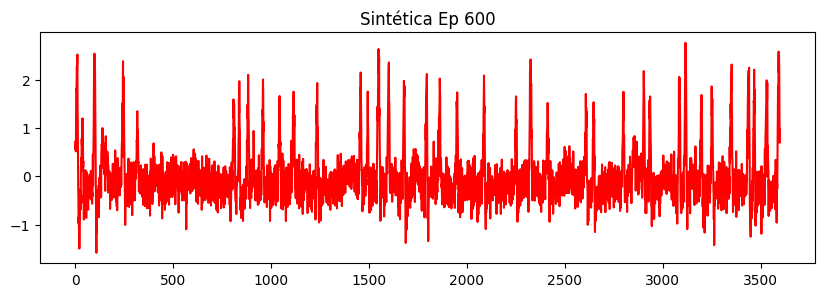

Epoch 700 | Loss: 0.00965 | DTW: 335.21


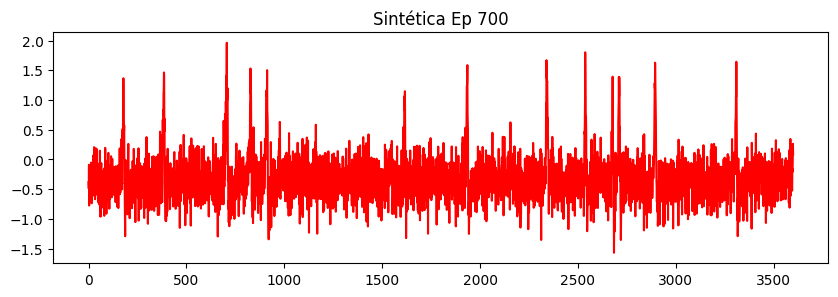

Epoch 800 | Loss: 0.01551 | DTW: 489.17


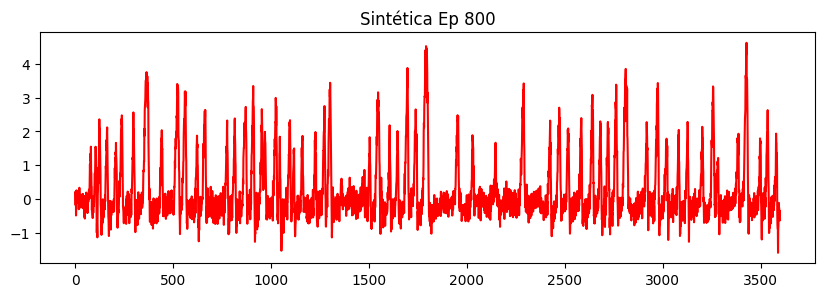

Epoch 900 | Loss: 0.00955 | DTW: 319.43


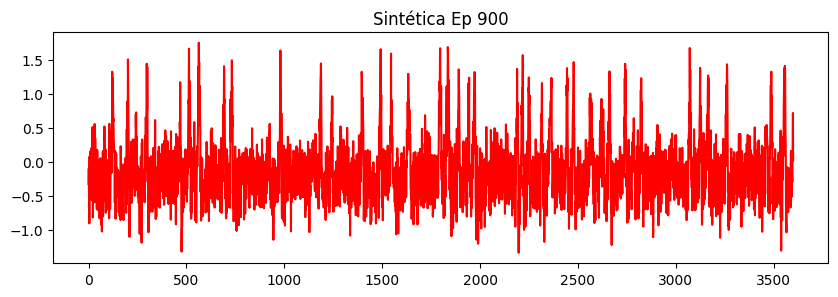

Epoch 1000 | Loss: 0.01054 | DTW: 284.11


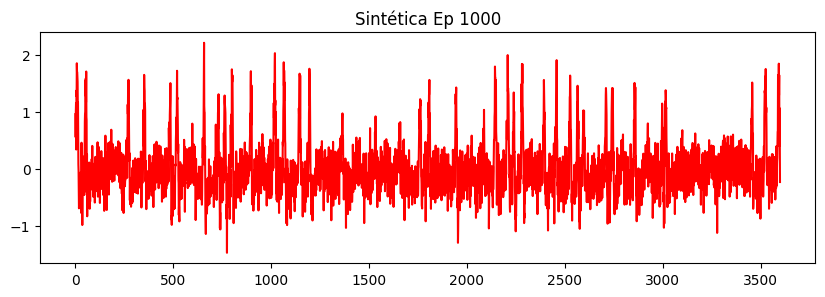

Epoch 1100 | Loss: 0.01111 | DTW: 365.09


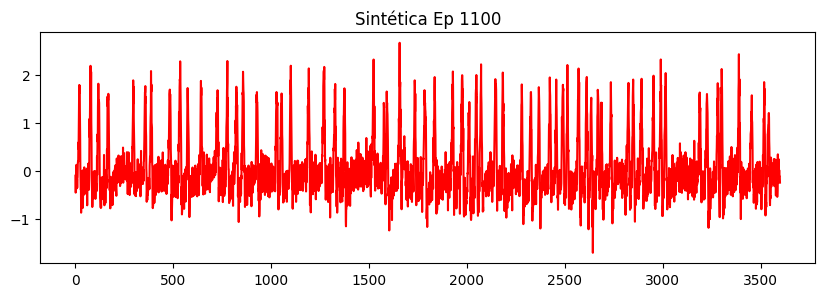

Epoch 1200 | Loss: 0.01255 | DTW: 256.97
⭐ ¡Mejor modelo guardado!


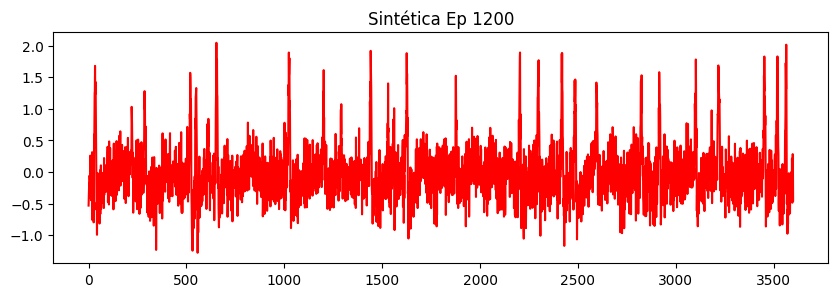

Epoch 1300 | Loss: 0.01008 | DTW: 344.97


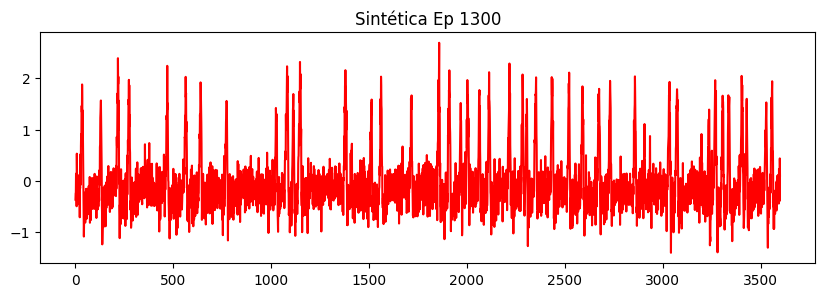

Epoch 1400 | Loss: 0.01425 | DTW: 353.53


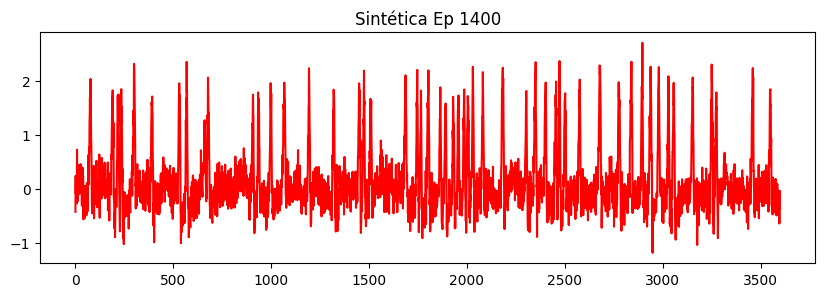

Epoch 1500 | Loss: 0.01229 | DTW: 249.16
⭐ ¡Mejor modelo guardado!


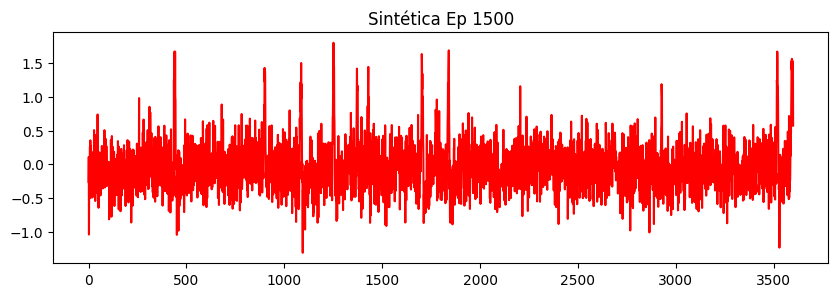

Epoch 1600 | Loss: 0.01481 | DTW: 234.77
⭐ ¡Mejor modelo guardado!


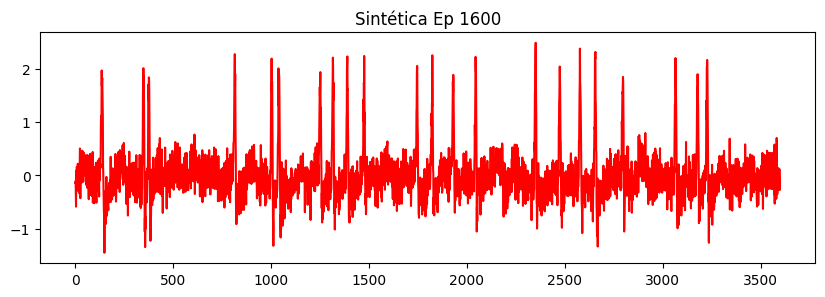

Epoch 1700 | Loss: 0.00950 | DTW: 333.87


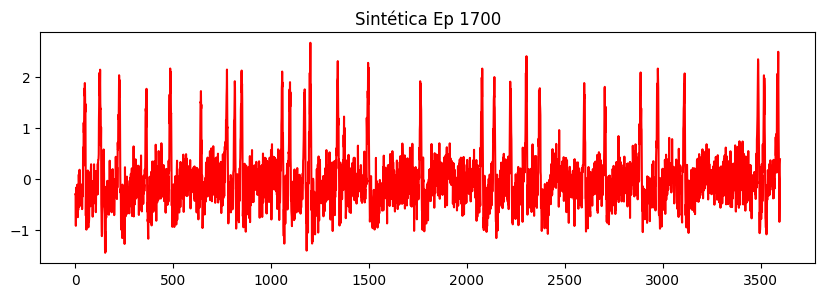

Epoch 1800 | Loss: 0.01753 | DTW: 267.47


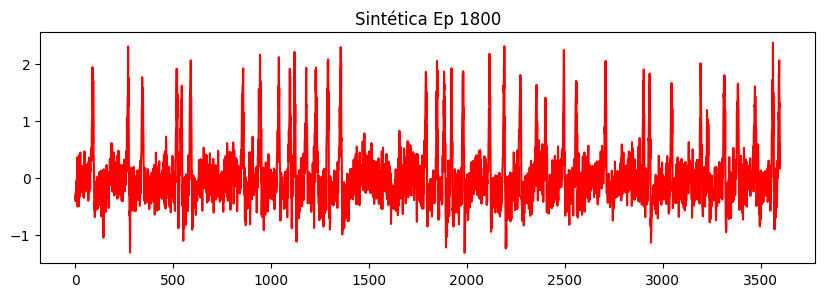

Epoch 1900 | Loss: 0.01197 | DTW: 197.08
⭐ ¡Mejor modelo guardado!


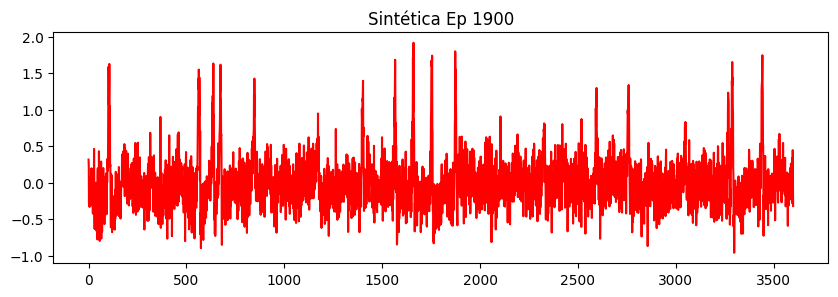

Epoch 2000 | Loss: 0.00884 | DTW: 317.10


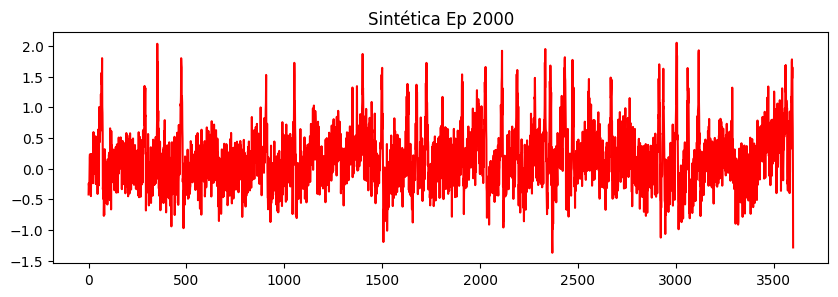

In [17]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from fastdtw import fastdtw
import pickle

# ==========================================
# 1. CONFIGURACIÓN Y DISPOSITIVO
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 1000  # Pasos de difusión

def get_cosine_schedule(T, s=0.008):
    steps = T + 1
    x = torch.linspace(0, T, steps)
    alphas_cumprod = torch.cos(((x / T) + s) / (1 + s) * np.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.02)

betas = get_cosine_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# ==========================================
# 2. MÉTRICAS DE EVALUACIÓN (DTW)
# ==========================================
def calculate_dtw_score(real_signals, fake_signals):
    dtw_distances = []
    num_samples = min(len(real_signals), len(fake_signals), 4) 
    for i in range(num_samples):
        r = real_signals[i].detach().cpu().numpy().flatten().astype(np.float64)
        f = fake_signals[i].flatten().astype(np.float64)
        # Downsampling x4 para velocidad en el cálculo de DTW (opcional)
        distance, _ = fastdtw(r[::4], f[::4], dist=lambda x, y: np.abs(x - y))
        dtw_distances.append(distance)
    return np.mean(dtw_distances)

# ==========================================
# 3. ARQUITECTURA DEL MODELO (BioDiffusion U-Net)
# ==========================================
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, dim),
            nn.LeakyReLU(0.2),
            nn.Linear(dim, dim),
        )
    def forward(self, t):
        return self.mlp(t).unsqueeze(-1)

class ResNetBlock(nn.Module):
    def __init__(self, channels, time_dim):
        super().__init__()
        self.time_mlp = nn.Linear(time_dim, channels)
        self.conv1 = nn.Conv1d(channels, channels, 3, padding=2, dilation=2)
        self.bn1 = nn.BatchNorm1d(channels)
        self.conv2 = nn.Conv1d(channels, channels, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        self.relu = nn.LeakyReLU(0.2)

    def forward(self, x, t_emb):
        h = self.bn1(self.relu(self.conv1(x)))
        h = h + self.time_mlp(t_emb.squeeze(-1)).unsqueeze(-1)
        h = self.bn2(self.relu(self.conv2(h)))
        return x + h

class BioDiffusionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.t_emb = TimeEmbedding(64)
        self.init_conv = nn.Conv1d(1, 64, 7, padding=3)
        
        # Encoder
        self.down1 = nn.Conv1d(64, 128, 4, stride=2, padding=1)
        self.res1 = ResNetBlock(128, 64)
        self.down2 = nn.Conv1d(128, 256, 4, stride=2, padding=1)
        self.res2 = ResNetBlock(256, 64)
        self.down3 = nn.Conv1d(256, 512, 4, stride=2, padding=1)
        
        # Bottleneck
        self.mid_res = ResNetBlock(512, 64)
        
        # Decoder
        self.up1 = nn.ConvTranspose1d(512, 256, 4, stride=2, padding=1)
        self.up2 = nn.ConvTranspose1d(256, 128, 4, stride=2, padding=1)
        self.up3 = nn.ConvTranspose1d(128, 64, 4, stride=2, padding=1)
        self.out_conv = nn.Conv1d(64, 1, 3, padding=1)

    def forward(self, x, t):
        t_embed = self.t_emb(t)
        x0 = self.init_conv(x)
        x1 = self.res1(self.down1(x0), t_embed)
        x2 = self.res2(self.down2(x1), t_embed)
        x3 = self.down3(x2)
        x = self.mid_res(x3, t_embed)
        x = self.up1(x)
        x = F.interpolate(x, size=x2.shape[-1])
        x = self.up2(x)
        x = F.interpolate(x, size=x1.shape[-1])
        x = self.up3(x)
        x = F.interpolate(x, size=3600)
        return self.out_conv(x)

# ==========================================
# 4. FUNCIÓN DE SAMPLING (GENERACIÓN)
# ==========================================
@torch.no_grad()
def sample_ecg(model, n_samples=1, device="cpu"):
    model.eval()
    x = torch.randn(n_samples, 1, 3600).to(device)
    for i in reversed(range(T)):
        t = torch.full((n_samples, 1), i / T).to(device)
        pred_noise = model(x, t)
        a, a_cap, b = alphas[i], alphas_cumprod[i], betas[i]
        noise = torch.randn_like(x) if i > 0 else 0
        x = (1 / torch.sqrt(a)) * (x - ((1 - a) / torch.sqrt(1 - a_cap)) * pred_noise) + torch.sqrt(b) * noise
    return x.cpu().squeeze().numpy()

# ==========================================
# 5. BUCLE DE ENTRENAMIENTO PRINCIPAL
# ==========================================
model = BioDiffusionUNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4)
criterion = nn.HuberLoss()
best_dtw = float('inf')

# --- El loader debe estar definido aquí con tus datos ---
# loader = DataLoader(TensorDataset(torch.tensor(signal, dtype=torch.float32).unsqueeze(1)), batch_size=32, shuffle=True)

epochs = 2000
for epoch in range(epochs):
    model.train()
    epoch_loss = 0
    for batch in loader:
        x_0 = batch[0].to(device)
        t = torch.randint(0, T, (x_0.shape[0],)).to(device)
        noise = torch.randn_like(x_0)
        
        x_noisy = sqrt_alphas_cumprod[t].view(-1, 1, 1) * x_0 + \
                  sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1) * noise
        
        pred = model(x_noisy, t.float().unsqueeze(1) / T)
        loss = criterion(pred, noise)
        
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()

    # Evaluación cada 100 épocas (excluyendo la 0)
    if (epoch + 1) % 100 == 0:
        model.eval()
        with torch.no_grad():
            gen_samples = sample_ecg(model, n_samples=4, device=device)
            current_dtw = calculate_dtw_score(x_0, gen_samples)
            print(f"Epoch {epoch+1} | Loss: {epoch_loss/len(loader):.5f} | DTW: {current_dtw:.2f}")
            
            if current_dtw < best_dtw:
                best_dtw = current_dtw
                torch.save(model.state_dict(), 'best_model_dtw.pth')
                print("⭐ ¡Mejor modelo guardado!")

            plt.figure(figsize=(10, 3))
            plt.plot(gen_samples[0], color='red')
            plt.title(f"Sintética Ep {epoch+1}")
            plt.show()

Epoch 100 | Loss: 0.0181 | DTW: 498.16


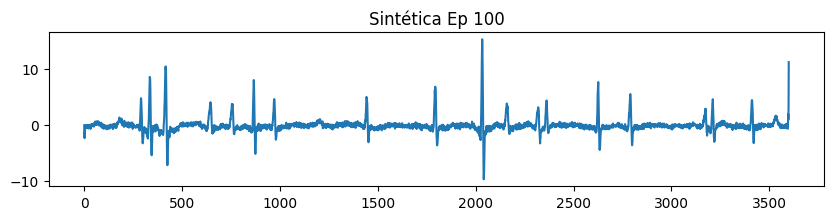

Epoch 200 | Loss: 0.0199 | DTW: 682.47


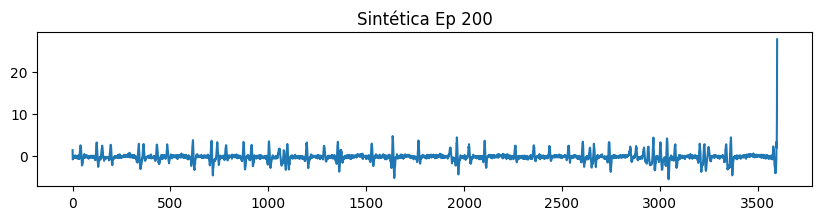

Epoch 300 | Loss: 0.0150 | DTW: 240.96


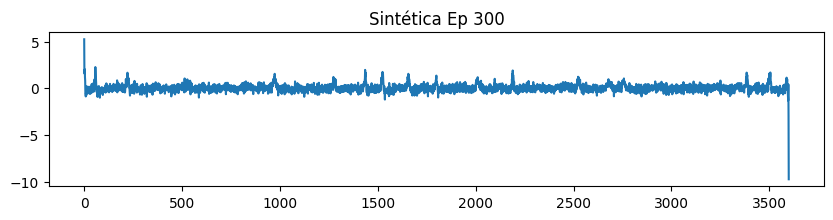

Epoch 400 | Loss: 0.0150 | DTW: 246.61


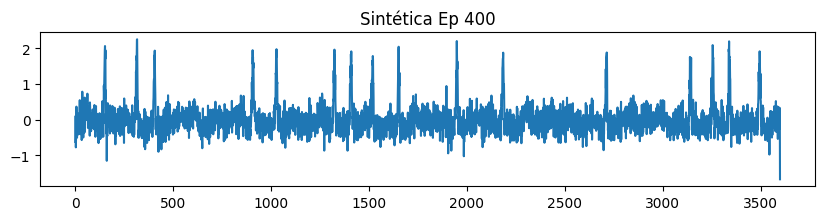

Epoch 500 | Loss: 0.0120 | DTW: 240.42


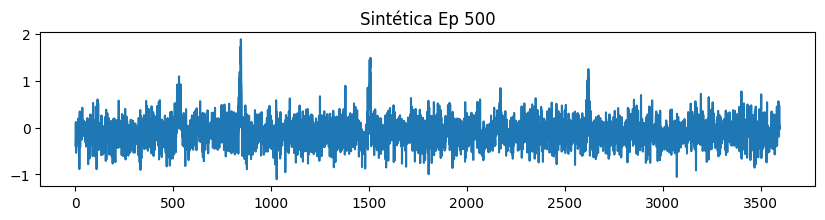

Epoch 600 | Loss: 0.0122 | DTW: 293.48


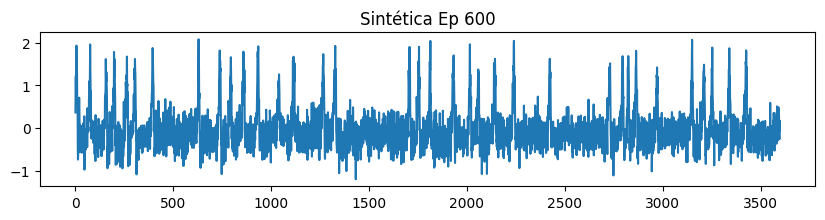

Epoch 700 | Loss: 0.0123 | DTW: 230.90


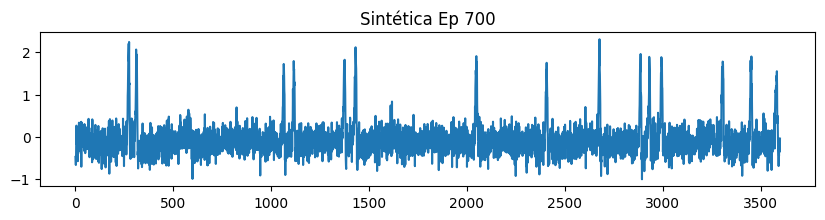

Epoch 800 | Loss: 0.0099 | DTW: 246.78


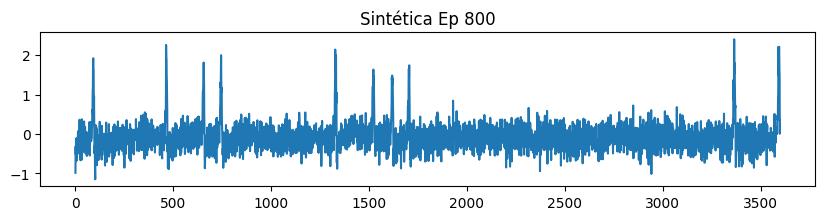

Epoch 900 | Loss: 0.0115 | DTW: 215.92


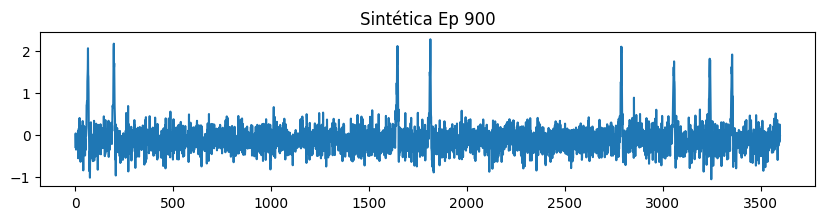

Epoch 1000 | Loss: 0.0149 | DTW: 285.33


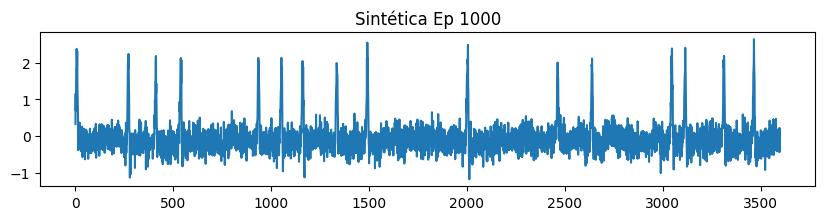

In [18]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset
from fastdtw import fastdtw
import pickle

# ==========================================
# 1. CONFIGURACIÓN Y DIFUSIÓN (COSINE)
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
T = 1000

def get_cosine_schedule(T, s=0.008):
    steps = T + 1
    x = torch.linspace(0, T, steps)
    alphas_cumprod = torch.cos(((x / T) + s) / (1 + s) * np.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.02)

betas = get_cosine_schedule(T).to(device)
alphas = 1.0 - betas
alphas_cumprod = torch.cumprod(alphas, dim=0).to(device)
sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
sqrt_one_minus_alphas_cumprod = torch.sqrt(1.0 - alphas_cumprod)

# ==========================================
# 2. BLOQUES DE RED NEURONAL MEJORADOS
# ==========================================

class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(1, dim),
            nn.Mish(),
            nn.Linear(dim, dim)
        )
    def forward(self, t):
        return self.mlp(t.view(-1, 1)).unsqueeze(-1)

class AttentionBlock(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.num_heads = 4
        self.mha = nn.MultiheadAttention(channels, self.num_heads, batch_first=True)
        self.ln = nn.LayerNorm(channels)

    def forward(self, x):
        b, c, l = x.shape
        x_in = x.permute(0, 2, 1) # (B, L, C)
        x_norm = self.ln(x_in)
        attn_out, _ = self.mha(x_norm, x_norm, x_norm)
        return (x_in + attn_out).permute(0, 2, 1)

class ResNetBlock(nn.Module):
    def __init__(self, in_ch, out_ch, time_dim, dilation=1):
        super().__init__()
        self.time_mlp = nn.Linear(time_dim, out_ch)
        self.conv1 = nn.Conv1d(in_ch, out_ch, 3, padding=dilation, dilation=dilation)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, 3, padding=1)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.relu = nn.LeakyReLU(0.2)
        self.shortcut = nn.Conv1d(in_ch, out_ch, 1) if in_ch != out_ch else nn.Identity()

    def forward(self, x, t_emb):
        h = self.bn1(self.relu(self.conv1(x)))
        h = h + self.time_mlp(t_emb.squeeze(-1)).unsqueeze(-1)
        h = self.bn2(self.relu(self.conv2(h)))
        return self.shortcut(x) + h

# ==========================================
# 3. ARQUITECTURA U-NET PROFUNDA (4 NIVELES)
# ==========================================
class BioDiffusionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.t_emb = TimeEmbedding(64)
        
        # Encoder
        self.init = nn.Conv1d(1, 64, 7, padding=3)
        self.d1 = nn.Conv1d(64, 128, 4, stride=2, padding=1)  # 1800
        self.r1 = ResNetBlock(128, 128, 64, dilation=1)
        self.d2 = nn.Conv1d(128, 256, 4, stride=2, padding=1) # 900
        self.r2 = ResNetBlock(256, 256, 64, dilation=2)
        self.d3 = nn.Conv1d(256, 512, 4, stride=2, padding=1) # 450
        
        # Bottleneck
        self.attn = AttentionBlock(512)
        self.mid = ResNetBlock(512, 512, 64, dilation=4)
        
        # Decoder
        self.u1 = nn.ConvTranspose1d(512, 256, 4, stride=2, padding=1)
        self.u2 = nn.ConvTranspose1d(256, 128, 4, stride=2, padding=1)
        self.u3 = nn.ConvTranspose1d(128, 64, 4, stride=2, padding=1)
        self.final = nn.Conv1d(64, 1, 3, padding=1)

    def forward(self, x, t):
        temb = self.t_emb(t)
        x0 = self.init(x)
        x1 = self.r1(self.d1(x0), temb)
        x2 = self.r2(self.d2(x1), temb)
        x3 = self.d3(x2)
        
        x = self.attn(x3)
        x = self.mid(x, temb)
        
        x = F.interpolate(self.u1(x), size=900)
        x = F.interpolate(self.u2(x), size=1800)
        x = F.interpolate(self.u3(x), size=3600)
        return self.final(x)

# ==========================================
# 4. FUNCIONES DE APOYO (SAMPLING Y DTW)
# ==========================================
@torch.no_grad()
def sample_ecg(model, n_samples=1, device="cpu"):
    model.eval()
    x = torch.randn(n_samples, 1, 3600).to(device)
    for i in reversed(range(T)):
        t = torch.full((n_samples, 1), i / T).to(device)
        pred_noise = model(x, t)
        a, a_cap, b = alphas[i], alphas_cumprod[i], betas[i]
        noise = torch.randn_like(x) if i > 0 else 0
        x = (1 / torch.sqrt(a)) * (x - ((1 - a) / torch.sqrt(1 - a_cap)) * pred_noise) + torch.sqrt(b) * noise
    return x.cpu().squeeze().numpy()

def calculate_dtw_score(real_signals, fake_signals):
    dtw_distances = []
    num_samples = min(len(real_signals), len(fake_signals), 4)
    for i in range(num_samples):
        r = real_signals[i].detach().cpu().numpy().flatten().astype(np.float64)
        f = fake_signals[i].flatten().astype(np.float64)
        # Downsampling para velocidad
        dist, _ = fastdtw(r[::4], f[::4], dist=lambda x, y: np.abs(x - y))
        dtw_distances.append(dist)
    return np.mean(dtw_distances)

# ==========================================
# 5. ENTRENAMIENTO
# ==========================================

model = BioDiffusionUNet().to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = nn.HuberLoss()
best_dtw = float('inf')

# loader = DataLoader(TensorDataset(torch.tensor(signal, dtype=torch.float32).unsqueeze(1)), batch_size=16, shuffle=True)

epochs = 1000 # Empieza con 1000
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in loader:
        x_0 = batch[0].to(device)
        t = torch.randint(0, T, (x_0.shape[0],)).to(device)
        noise = torch.randn_like(x_0)
        
        x_noisy = sqrt_alphas_cumprod[t].view(-1, 1, 1) * x_0 + \
                  sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1) * noise
        
        pred = model(x_noisy, t.float() / T)
        loss = criterion(pred, noise)
        
        optimizer.zero_grad(); loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    if (epoch + 1) % 100 == 0:
        model.eval()
        with torch.no_grad():
            gen = sample_ecg(model, n_samples=2, device=device)
            dtw = calculate_dtw_score(x_0, gen)
            print(f"Epoch {epoch+1} | Loss: {total_loss/len(loader):.4f} | DTW: {dtw:.2f}")
            
            if dtw < best_dtw:
                best_dtw = dtw
                torch.save(model.state_dict(), 'best_model.pth')
            
            plt.figure(figsize=(10, 2))
            plt.plot(gen[0] if gen.ndim > 1 else gen)
            plt.title(f"Sintética Ep {epoch+1}")
            plt.show()